# Modelo no supervisado KMEANS


## Explicacion
Una imagen a 4 bandas puede ser representada de la forma xi = [b1,b2,b3,b4], los bi hacen referencia a las intensidades registradas por cada banda,esto siento interpretado como una firma espectral de dicha imagen en 4 bandas.

In [2]:
import os
import cv2
import numpy as np
import pandas as pd

def analizar_imagenes(carpeta):
    """
    Analiza todas las imágenes en una carpeta y devuelve un resumen con información básica.
    
    Parámetros:
        carpeta (str): ruta de la carpeta que contiene las imágenes.
    
    Retorna:
        DataFrame con la información relevante de cada imagen.
    """
    info_imagenes = []

    # Obtener lista de archivos
    archivos = [f for f in os.listdir(carpeta) if f.lower().endswith(('.png', '.jpg', '.jpeg', '.tif', '.tiff'))]

    if not archivos:
        print("⚠️ No se encontraron imágenes en la carpeta.")
        return None

    for nombre in archivos:
        ruta = os.path.join(carpeta, nombre)
        img = cv2.imread(ruta, cv2.IMREAD_UNCHANGED)  # Lee la imagen sin alterar canales ni profundidad

        if img is None:
            print(f"❌ No se pudo leer la imagen: {nombre}")
            continue

        alto, ancho = img.shape[:2]
        canales = 1 if len(img.shape) == 2 else img.shape[2]
        tipo_dato = img.dtype

        # Calcular estadísticas por canal
        min_val = img.min(axis=(0, 1)) if canales > 1 else [img.min()]
        max_val = img.max(axis=(0, 1)) if canales > 1 else [img.max()]
        mean_val = img.mean(axis=(0, 1)) if canales > 1 else [img.mean()]

        info_imagenes.append({
            "Archivo": nombre,
            "Altura": alto,
            "Anchura": ancho,
            "Canales": canales,
            "TipoDato": tipo_dato,
            "Mínimo": np.round(min_val, 2).tolist(),
            "Máximo": np.round(max_val, 2).tolist(),
            "Promedio": np.round(mean_val, 2).tolist()
        })

    df_info = pd.DataFrame(info_imagenes)
    print("✅ Análisis completado. Resumen general:")
    print(df_info.head())

    return df_info

r_f = r"E:\Proyects Python based\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\src\Multiespectral_Data"
analizar_imagenes(r_f)


✅ Análisis completado. Resumen general:
                              Archivo  Altura  Anchura  Canales TipoDato  \
0  VIS_frame_-0001_multispectral.tiff    1944     2592        4    uint8   
1  VIS_frame_00002_multispectral.tiff    1944     2592        4    uint8   
2  VIS_frame_00007_multispectral.tiff    1944     2592        4    uint8   
3  VIS_frame_00012_multispectral.tiff    1944     2592        4    uint8   
4  VIS_frame_00017_multispectral.tiff    1944     2592        4    uint8   

          Mínimo                Máximo                       Promedio  
0  [7, 6, 7, 29]  [252, 254, 254, 255]   [59.47, 59.23, 63.78, 123.5]  
1  [9, 8, 9, 35]  [249, 254, 250, 255]  [62.07, 67.24, 76.05, 134.32]  
2  [9, 8, 9, 38]  [254, 255, 255, 255]  [61.07, 65.49, 74.11, 129.57]  
3  [8, 8, 9, 36]  [237, 237, 254, 255]   [56.52, 59.25, 66.8, 122.86]  
4  [8, 7, 8, 36]  [254, 255, 254, 255]  [58.27, 60.23, 66.98, 117.66]  


,Archivo,Altura,Anchura,Canales,TipoDato,Mínimo,Máximo,Promedio
0,VIS_frame_-0001_multispectral.tiff,1944,2592,4,uint8,"[7, 6, 7, 29]","[252, 254, 254, 255]","[59.47, 59.23, 63.78, 123.5]"
1,VIS_frame_00002_multispectral.tiff,1944,2592,4,uint8,"[9, 8, 9, 35]","[249, 254, 250, 255]","[62.07, 67.24, 76.05, 134.32]"
2,VIS_frame_00007_multispectral.tiff,1944,2592,4,uint8,"[9, 8, 9, 38]","[254, 255, 255, 255]","[61.07, 65.49, 74.11, 129.57]"
3,VIS_frame_00012_multispectral.tiff,1944,2592,4,uint8,"[8, 8, 9, 36]","[237, 237, 254, 255]","[56.52, 59.25, 66.8, 122.86]"
4,VIS_frame_00017_multispectral.tiff,1944,2592,4,uint8,"[8, 7, 8, 36]","[254, 255, 254, 255]","[58.27, 60.23, 66.98, 117.66]"
...,...,...,...,...,...,...,...,...
62,VIS_frame_00938_multispectral.tiff,1944,2592,4,uint8,"[16, 13, 13, 38]","[229, 232, 230, 249]","[66.67, 58.37, 61.15, 125.65]"
63,VIS_frame_00961_multispectral.tiff,1944,2592,4,uint8,"[17, 14, 14, 36]","[222, 224, 222, 255]","[61.28, 52.99, 55.33, 117.81]"
64,VIS_frame_00980_multispectral.tiff,1944,2592,4,uint8,"[14, 11, 12, 36]","[189, 189, 187, 248]","[63.82, 54.57, 56.76, 119.12]"
65,VIS_frame_01006_multispectral.tiff,1944,2592,4,uint8,"[18, 15, 16, 43]","[207, 183, 195, 255]","[64.34, 55.28, 57.19, 121.75]"


In [3]:
import os
import numpy as np
from tifffile import imread
from sklearn.preprocessing import MinMaxScaler, StandardScaler

def preprocess_all_tiffs_in_folder(folder_path, normalization="minmax"):
    """
    Lee todas las imágenes .tif en una carpeta, las convierte a matrices (N_pixeles, 4),
    elimina valores nulos y normaliza las 4 bandas.

    Parámetros:
    ------------
    folder_path : str
        Ruta de la carpeta que contiene las imágenes .tif.
    normalization : str
        Método de normalización ("minmax" o "zscore").

    Retorna:
    ---------
    results : list of dict
        Lista con un diccionario por imagen:
        {
            'filename': nombre del archivo,
            'data': matriz (N_pixeles, 4) normalizada,
            'shape': forma original (alto, ancho, bandas)
        }
    """

    results = []
    tif_files = [f for f in os.listdir(folder_path) if f.lower().endswith(".tiff")]

    if not tif_files:
        raise ValueError("⚠️ No se encontraron archivos .tif en la carpeta especificada.")

    print(f"🧩 Procesando {len(tif_files)} imágenes TIFF...\n")

    for fname in tif_files:
        tiff_path = os.path.join(folder_path, fname)

        # 1️⃣ Leer imagen
        img = imread(tiff_path).astype(np.float32)

        # 2️⃣ Asegurar orden correcto (alto, ancho, bandas)
        if img.shape[0] == 4 and img.shape[-1] != 4:
            img = np.moveaxis(img, 0, -1)  # mover (bandas, alto, ancho) → (alto, ancho, bandas)

        h, w, bands = img.shape
        if bands != 4:
            print(f"⚠️ Imagen {fname} tiene {bands} bandas (se esperaban 4). Se omite.")
            continue

        # 3️⃣ Convertir a matriz de píxeles
        pixels = img.reshape(-1, 4)

        # 4️⃣ Eliminar valores NaN o NoData
        mask = ~np.isnan(pixels).any(axis=1)
        pixels_clean = pixels[mask]

        # 5️⃣ Normalizar
        if normalization == "minmax":
            scaler = MinMaxScaler()
        elif normalization == "zscore":
            scaler = StandardScaler()
        else:
            raise ValueError("normalization debe ser 'minmax' o 'zscore'.")

        pixels_norm = scaler.fit_transform(pixels_clean)

        # 6️⃣ Guardar resultados
        results.append({
            'filename': fname,
            'data': pixels_norm,
            'shape': (h, w, 4)
        })

        print(f"✅ {fname} procesada: {pixels_norm.shape[0]} píxeles válidos.")

    print("\n🎯 Preprocesamiento completado para todas las imágenes.")
    return results
folder_path1 = r"E:\Proyects Python based\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\src\Multiespectral_Data"
preproces = preprocess_all_tiffs_in_folder(folder_path1, normalization="minmax")

🧩 Procesando 67 imágenes TIFF...

✅ VIS_frame_-0001_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00002_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00007_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00012_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00017_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00023_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00027_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00028_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00029_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00030_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00031_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00032_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00033_multispectral.tiff procesada: 5038848 píxeles válidos.
✅ VIS_frame_00034

In [4]:
import numpy as np
import random

def build_representative_sample(processed_data, samples_per_image=1000, validation_fraction=0.1, random_state=42):
    """
    Toma muestras aleatorias de píxeles de cada imagen preprocesada y construye
    un dataset global para K-Means, junto con una muestra de validación.

    Parámetros:
    ------------
    processed_data : list of dict
        Resultado de la función preprocess_all_tiffs_in_folder().
    samples_per_image : int
        Número de píxeles a muestrear por imagen.
    validation_fraction : float
        Porcentaje del dataset total reservado para validación.
    random_state : int
        Semilla para reproducibilidad.

    Retorna:
    ---------
    train_data : np.ndarray
        Matriz de entrenamiento (N_train, 4)
    val_data : np.ndarray
        Matriz de validación (N_val, 4)
    """

    np.random.seed(random_state)
    random.seed(random_state)

    all_samples = []

    for img_info in processed_data:
        pixels = img_info['data']
        n_pixels = pixels.shape[0]

        if n_pixels <= samples_per_image:
            sample = pixels  # si tiene menos, se usa todo
        else:
            idx = np.random.choice(n_pixels, samples_per_image, replace=False)
            sample = pixels[idx]

        all_samples.append(sample)

    # 1️⃣ Concatenar todo en un solo dataset global
    global_data = np.vstack(all_samples)
    print(f"✅ Dataset global: {global_data.shape[0]:,} píxeles muestreados ({global_data.shape[1]} bandas)")

    # 2️⃣ Separar entrenamiento y validación
    n_total = global_data.shape[0]
    n_val = int(n_total * validation_fraction)
    indices = np.random.permutation(n_total)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    val_data = global_data[val_idx]
    train_data = global_data[train_idx]

    print(f"📊 División: {train_data.shape[0]:,} entrenamiento / {val_data.shape[0]:,} validación")

    return train_data, val_data
folder_path2 = r"E:\Proyects Python based\OT-Detecci-n-de-objetos-VIS-NIR-ML-Colombia\src\Multiespectral_Data"

rep_sample = build_representative_sample(preproces, samples_per_image=10000, validation_fraction=0.1, random_state=42)


✅ Dataset global: 670,000 píxeles muestreados (4 bandas)
📊 División: 603,000 entrenamiento / 67,000 validación


In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import numpy as np

def train_kmeans(X_train, X_val, n_clusters_list, random_state=42):
    best_model = None
    best_score = -1
    results = []

    for k in n_clusters_list:
        print(f"Entrenando K-Means con k={k}...")
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        kmeans.fit(X_train)

        labels = kmeans.predict(X_val)
        score = silhouette_score(X_val, labels)
        results.append((k, score))
        print(f"→ Silhouette Score: {score:.4f}")

        if score > best_score:
            best_score = score
            best_model = kmeans

    print("\n📊 Resultados comparativos:")
    for k, s in results:
        print(f"k={k}: silhouette={s:.4f}")

    joblib.dump(best_model, "modelo_kmeans.pkl")
    print(f"\n✅ Modelo guardado como 'modelo_kmeans.pkl' con k={best_model.n_clusters}")

    return best_model
best_kmeans_model = train_kmeans(rep_sample[0], rep_sample[1], n_clusters_list=[4], random_state=42)


Entrenando K-Means con k=4...
→ Silhouette Score: 0.3261

📊 Resultados comparativos:
k=4: silhouette=0.3261

✅ Modelo guardado como 'modelo_kmeans.pkl' con k=4


🖼️ Segmentando imagen 2: VIS_frame_00002_multispectral.tiff


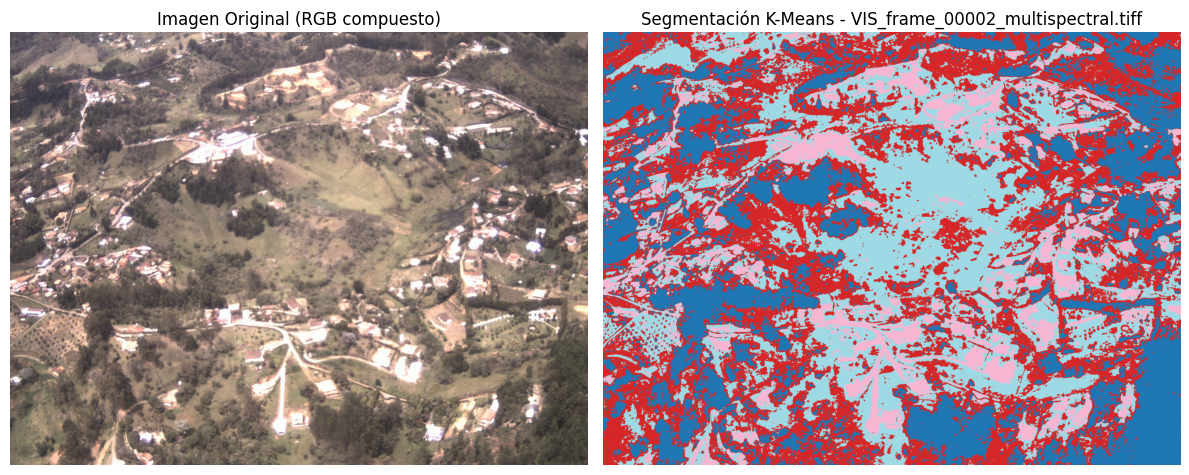

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0]], shape=(1944, 2592), dtype=int32)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread
import joblib
from pathlib import Path

def segment_image_from_folder(folder_path, image_index=0, model_path="modelo_kmeans.pkl", normalization="minmax"):
    """
    Aplica el modelo K-Means entrenado a una imagen TIFF seleccionada por índice dentro de una carpeta
    y muestra la imagen original junto con la segmentada.

    Parámetros:
    ------------
    folder_path : str o Path
        Ruta a la carpeta que contiene las imágenes TIFF.
    image_index : int
        Índice de la imagen a segmentar (0 = primera imagen).
    model_path : str
        Ruta al modelo K-Means entrenado (formato .pkl).
    normalization : str
        Tipo de normalización: "minmax" o "zscore".

    Retorna:
    --------
    segmented : np.ndarray
        Imagen segmentada (matriz de etiquetas de clusters).
    """

    folder = Path(folder_path)
    tiff_files = sorted(list(folder.glob("*.tif")) + list(folder.glob("*.tiff")) + list(folder.glob("*.TIF")) + list(folder.glob("*.TIFF")))

    if not tiff_files:
        raise FileNotFoundError(f"No se encontraron imágenes TIFF en {folder}")
    if image_index >= len(tiff_files):
        raise IndexError(f"Índice fuera de rango. Solo hay {len(tiff_files)} imágenes.")

    # 1️⃣ Seleccionar imagen
    image_path = tiff_files[image_index]
    print(f"🖼️ Segmentando imagen {image_index}: {image_path.name}")

    # 2️⃣ Cargar modelo
    kmeans = joblib.load(model_path)

    # 3️⃣ Leer imagen TIFF
    img = imread(image_path).astype(np.float32)
    if img.shape[0] == 4 and img.shape[-1] != 4:
        img = np.moveaxis(img, 0, -1)

    h, w, b = img.shape
    pixels = img.reshape(-1, b)

    # 4️⃣ Normalizar igual que en entrenamiento
    if normalization == "minmax":
        pixels = (pixels - pixels.min(axis=0)) / (pixels.max(axis=0) - pixels.min(axis=0) + 1e-8)
    elif normalization == "zscore":
        pixels = (pixels - pixels.mean(axis=0)) / (pixels.std(axis=0) + 1e-8)

    # 5️⃣ Predecir cluster de cada píxel
    labels = kmeans.predict(pixels)
    segmented = labels.reshape(h, w)

    # 6️⃣ Visualizar resultado (original + segmentada)
    plt.figure(figsize=(12, 6))

    # Imagen original (usando bandas visibles si hay más de 3)
    plt.subplot(1, 2, 1)
    plt.title("Imagen Original (RGB compuesto)")
    if b >= 3:
        plt.imshow(img[..., :3] / np.max(img[..., :3]))  # normaliza para visualizar
    else:
        plt.imshow(img[..., 0], cmap="gray")
    plt.axis("off")

    # Imagen segmentada
    plt.subplot(1, 2, 2)
    plt.title(f"Segmentación K-Means - {image_path.name}")
    plt.imshow(segmented, cmap="tab20")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

    return segmented


# === Ejemplo de uso ===
import joblib
joblib.dump(best_kmeans_model, "modelo_kmeans.pkl")

segment_image_from_folder(r_f, image_index=2, model_path="modelo_kmeans.pkl", normalization="minmax")


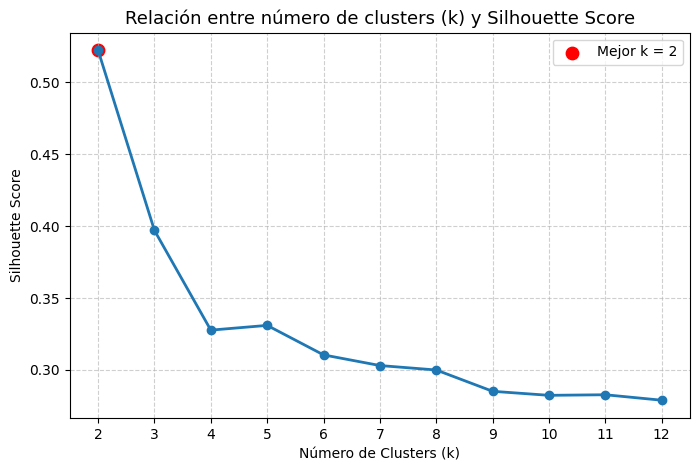

In [7]:
import matplotlib.pyplot as plt

# Datos experimentales
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
silhouette_scores = [0.5221, 0.3969, 0.3276, 0.3309, 0.3104, 0.3030, 0.2999, 0.2851, 0.2823, 0.2827, 0.2789]

# Crear gráfico
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', linewidth=2)
plt.title("Relación entre número de clusters (k) y Silhouette Score", fontsize=13)
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(k_values)
plt.scatter(2, 0.5221, color='red', s=80, label="Mejor k = 2")
plt.legend()
plt.show()


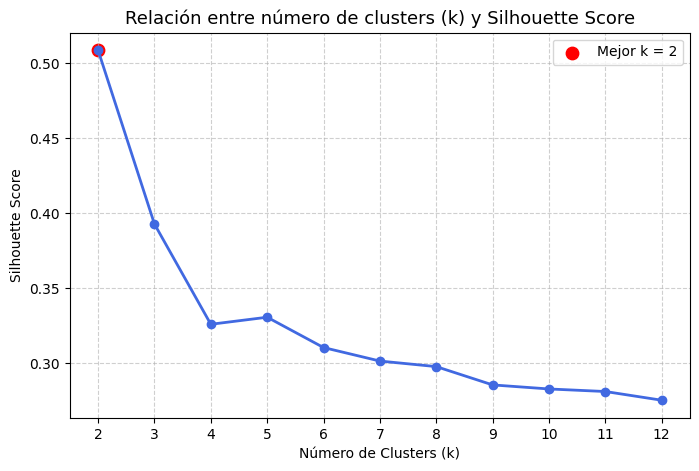

In [10]:
import matplotlib.pyplot as plt

# Datos experimentales
k_values = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
silhouette_scores = [0.5087, 0.3929, 0.3261, 0.3308, 0.3106, 0.3016, 0.2979, 0.2857, 0.2830, 0.2813, 0.2755]

# Crear gráfico
plt.figure(figsize=(8,5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', linewidth=2, color='royalblue')
plt.title("Relación entre número de clusters (k) y Silhouette Score", fontsize=13)
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True, linestyle='--', alpha=0.6)
plt.xticks(k_values)
plt.scatter(2, 0.5087, color='red', s=80, label="Mejor k = 2")
plt.legend()
plt.show()


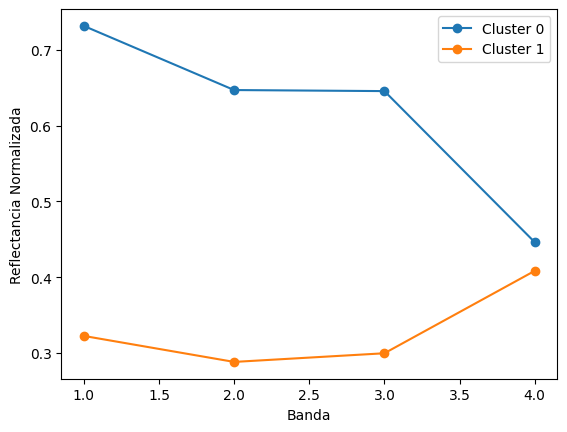

In [11]:
import matplotlib.pyplot as plt

centers = best_kmeans_model.cluster_centers_
for i, c in enumerate(centers):
    plt.plot(range(1,5), c, marker='o', label=f'Cluster {i}')
plt.xlabel('Banda')
plt.ylabel('Reflectancia Normalizada')
plt.legend()
plt.show()
